In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy.stats import pearsonr, spearmanr

In [9]:
def carregar_serie_bcb_em_blocos(codigo, nome, blocos):
    dfs = []

    for data_inicial, data_final in blocos:
        url = (
            f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"
            f"?formato=json&dataInicial={data_inicial}&dataFinal={data_final}"
        )

        response = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"}
        )

        if response.status_code != 200:
            print("Erro na requisição")
            print("Código:", response.status_code)
            print("URL:", url)
            print("Resposta:", response.text[:500])
            response.raise_for_status()

        dados = response.json()

        df_temp = pd.DataFrame(dados)
        df_temp["data"] = pd.to_datetime(df_temp["data"], dayfirst=True)
        df_temp["valor"] = pd.to_numeric(df_temp["valor"], errors="coerce")

        dfs.append(df_temp)

    df = pd.concat(dfs, ignore_index=True)

    df = (
        df
        .drop_duplicates(subset=["data"])
        .sort_values("data")
        .rename(columns={"valor": nome})
        [["data", nome]]
    )

    return df

In [11]:
blocos_dolar = [
    ("01/01/2014", "31/12/2019"),
    ("01/01/2020", "31/12/2025")
]

dolar = carregar_serie_bcb_em_blocos(
    codigo=1,
    nome="dolar",
    blocos=blocos_dolar
)

dolar.head(-5)

,data,dolar
0,2014-01-02,2.3975
1,2014-01-03,2.3741
2,2014-01-06,2.3789
3,2014-01-07,2.3634
4,2014-01-08,2.3779
...,...,...
3003,2025-12-17,5.5093
3004,2025-12-18,5.5283
3005,2025-12-19,5.5160
3006,2025-12-22,5.5389


In [12]:
dolar_mensal = (
    dolar
    .set_index("data")
    .resample("M")
    .mean()
    .reset_index()
)

dolar_mensal.head()

C:\Users\User\AppData\Local\Temp\ipykernel_132596\2844460126.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,data,dolar
0,2014-01-31,2.382209
1,2014-02-28,2.383680
2,2014-03-31,2.326089
3,2014-04-30,2.232770
4,2014-05-31,2.220881


In [13]:
def carregar_serie_bcb(codigo, nome, data_inicial="01/01/2014", data_final="31/12/2025"):
    url = (
        f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"
        f"?formato=json&dataInicial={data_inicial}&dataFinal={data_final}"
    )

    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    if response.status_code != 200:
        print("Erro na requisição")
        print("Código:", response.status_code)
        print("URL:", url)
        print("Resposta:", response.text[:500])
        response.raise_for_status()

    dados = response.json()

    df = pd.DataFrame(dados)
    df["data"] = pd.to_datetime(df["data"], dayfirst=True)
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

    df = df.rename(columns={"valor": nome})
    df = df[["data", nome]]

    return df

In [14]:
inad = carregar_serie_bcb(
    codigo=21082,
    nome="inadimplencia_total",
    data_inicial="01/01/2014",
    data_final="31/12/2025"
)

selic = carregar_serie_bcb(
    codigo=4390,
    nome="selic",
    data_inicial="01/01/2014",
    data_final="31/12/2025"
)

ipca = carregar_serie_bcb(
    codigo=433,
    nome="ipca",
    data_inicial="01/01/2014",
    data_final="31/12/2025"
)

In [15]:
inad_mensal = (
    inad
    .set_index("data")
    .resample("M")
    .mean()
    .reset_index()
)

selic_mensal = (
    selic
    .set_index("data")
    .resample("M")
    .mean()
    .reset_index()
)

ipca_mensal = (
    ipca
    .set_index("data")
    .resample("M")
    .mean()
    .reset_index()
)

C:\Users\User\AppData\Local\Temp\ipykernel_132596\231684983.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
C:\Users\User\AppData\Local\Temp\ipykernel_132596\231684983.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
C:\Users\User\AppData\Local\Temp\ipykernel_132596\231684983.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


In [16]:
df_series = (
    inad_mensal
    .merge(selic_mensal, on="data", how="inner")
    .merge(dolar_mensal, on="data", how="inner")
    .merge(ipca_mensal, on="data", how="inner")
)

df_series.head()

,data,inadimplencia_total,selic,dolar,ipca
0,2014-01-31,2.84,0.85,2.382209,0.55
1,2014-02-28,2.86,0.79,2.383680,0.69
2,2014-03-31,2.88,0.77,2.326089,0.92
3,2014-04-30,2.92,0.82,2.232770,0.67
4,2014-05-31,3.00,0.87,2.220881,0.46


In [17]:
df_series.info()
df_series.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 144 non-null    datetime64[ns]
 1   inadimplencia_total  144 non-null    float64       
 2   selic                144 non-null    float64       
 3   dolar                144 non-null    float64       
 4   ipca                 144 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 5.8 KB


,data,inadimplencia_total,selic,dolar,ipca
count,144,144.000000,144.000000,144.000000,144.000000
mean,2020-01-14 21:30:00,3.121736,0.782361,4.304564,0.462153
min,2014-01-31 00:00:00,2.110000,0.130000,2.220881,-0.680000
25%,2017-01-23 06:00:00,2.887500,0.520000,3.288740,0.230000
50%,2020-01-15 12:00:00,3.090000,0.860000,4.152404,0.420000
75%,2023-01-07 18:00:00,3.462500,1.050000,5.279816,0.695000
max,2025-12-31 00:00:00,4.050000,1.280000,6.097029,1.620000
std,NaN,0.457974,0.313570,1.084231,0.391317


Como a inadimplência da carteira de crédito no Brasil evoluiu entre 2014 e 2025 e qual sua relação com a taxa Selic e o dólar comercial?1

In [18]:
df_series = df_series.sort_values("data").reset_index(drop=True)
df_series.head()

,data,inadimplencia_total,selic,dolar,ipca
0,2014-01-31,2.84,0.85,2.382209,0.55
1,2014-02-28,2.86,0.79,2.383680,0.69
2,2014-03-31,2.88,0.77,2.326089,0.92
3,2014-04-30,2.92,0.82,2.232770,0.67
4,2014-05-31,3.00,0.87,2.220881,0.46


In [19]:
df_series["ano"] = df_series["data"].dt.year
df_series["mes"] = df_series["data"].dt.month
df_series["ano_mes"] = df_series["data"].dt.to_period("M")

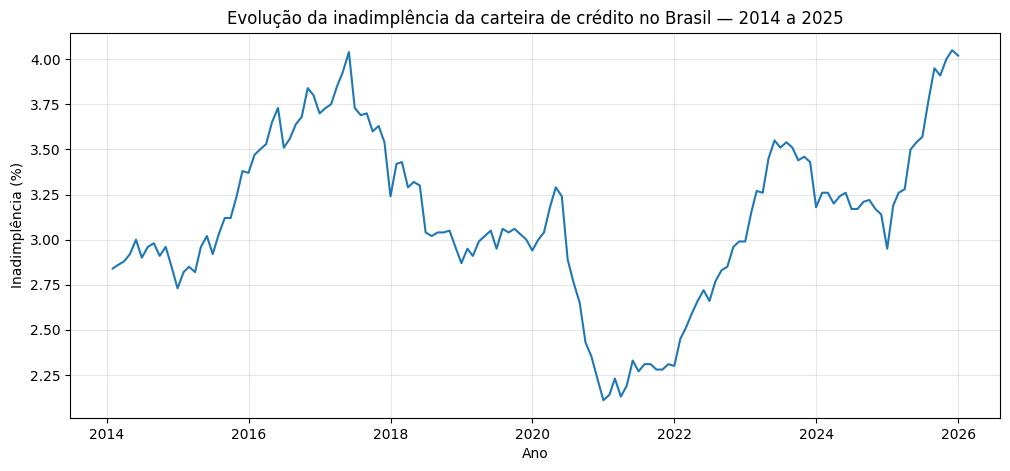

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df_series,
    x="data",
    y="inadimplencia_total"
)

plt.title("Evolução da inadimplência da carteira de crédito no Brasil — 2014 a 2025")
plt.xlabel("Ano")
plt.ylabel("Inadimplência (%)")
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
df_series["inadimplencia_total"].describe()

count    144.000000
mean       3.121736
std        0.457974
min        2.110000
25%        2.887500
50%        3.090000
75%        3.462500
max        4.050000
Name: inadimplencia_total, dtype: float64

In [22]:
print("Menor inadimplência:")
display(df_series.loc[df_series["inadimplencia_total"].idxmin(), ["data", "inadimplencia_total"]])

print("Maior inadimplência:")
display(df_series.loc[df_series["inadimplencia_total"].idxmax(), ["data", "inadimplencia_total"]])

Menor inadimplência:


data                   2020-12-31 00:00:00
inadimplencia_total                   2.11
Name: 83, dtype: object

Maior inadimplência:


data                   2025-11-30 00:00:00
inadimplencia_total                   4.05
Name: 142, dtype: object

In [23]:
inad_anual = (
    df_series
    .groupby("ano", as_index=False)
    .agg(
        inadimplencia_media=("inadimplencia_total", "mean"),
        selic_media=("selic", "mean"),
        dolar_medio=("dolar", "mean")
    )
)

inad_anual

,ano,inadimplencia_media,selic_media,dolar_medio
0,2014,2.899167,0.866667,2.353553
1,2015,3.054167,1.045000,3.331539
2,2016,3.634167,1.100000,3.490114
3,2017,3.702500,0.794167,3.192013
4,2018,3.148333,0.520000,3.654437
5,2019,3.000000,0.482500,3.945086
6,2020,2.764167,0.226667,5.155840
7,2021,2.256667,0.362500,5.395027
8,2022,2.748333,0.977500,5.164753
9,2023,3.395833,1.025833,4.994980


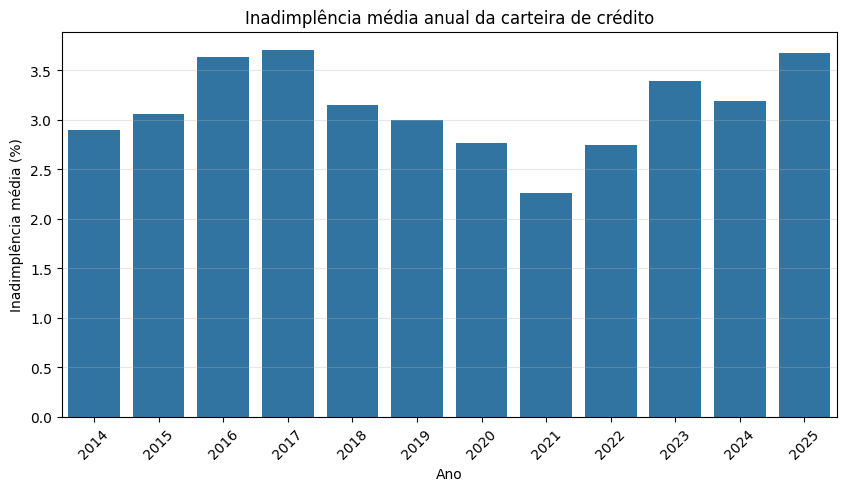

In [24]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=inad_anual,
    x="ano",
    y="inadimplencia_media"
)

plt.title("Inadimplência média anual da carteira de crédito")
plt.xlabel("Ano")
plt.ylabel("Inadimplência média (%)")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [25]:
df_series["inad_mm3"] = df_series["inadimplencia_total"].rolling(window=3).mean()
df_series["inad_mm12"] = df_series["inadimplencia_total"].rolling(window=12).mean()

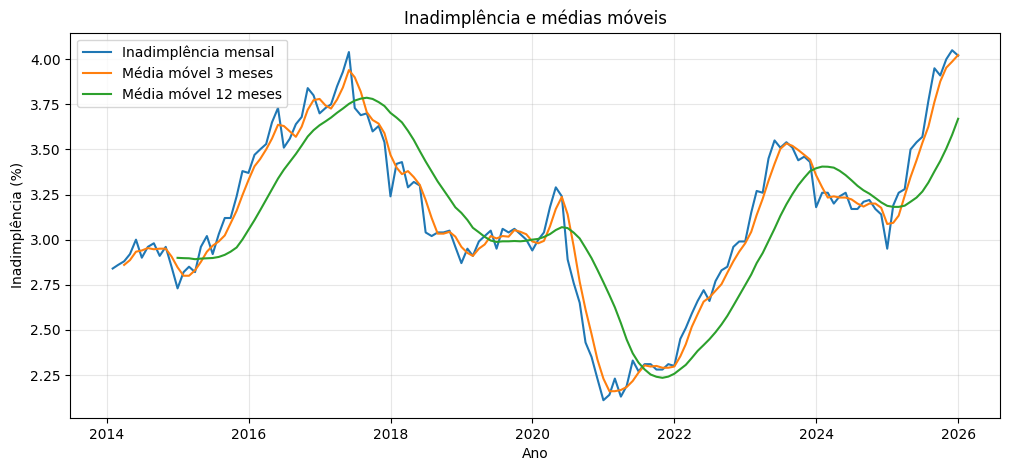

In [26]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=df_series, x="data", y="inadimplencia_total", label="Inadimplência mensal")
sns.lineplot(data=df_series, x="data", y="inad_mm3", label="Média móvel 3 meses")
sns.lineplot(data=df_series, x="data", y="inad_mm12", label="Média móvel 12 meses")

plt.title("Inadimplência e médias móveis")
plt.xlabel("Ano")
plt.ylabel("Inadimplência (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

A média móvel de 3 meses suaviza oscilações de curto prazo, enquanto a média móvel de 12 meses permite visualizar a tendência anual da inadimplência. Essa abordagem facilita a identificação de ciclos de alta ou queda na série.

In [27]:
df_norm = df_series.copy()

for col in ["inadimplencia_total", "selic", "dolar"]:
    df_norm[col + "_z"] = (
        df_norm[col] - df_norm[col].mean()
    ) / df_norm[col].std()

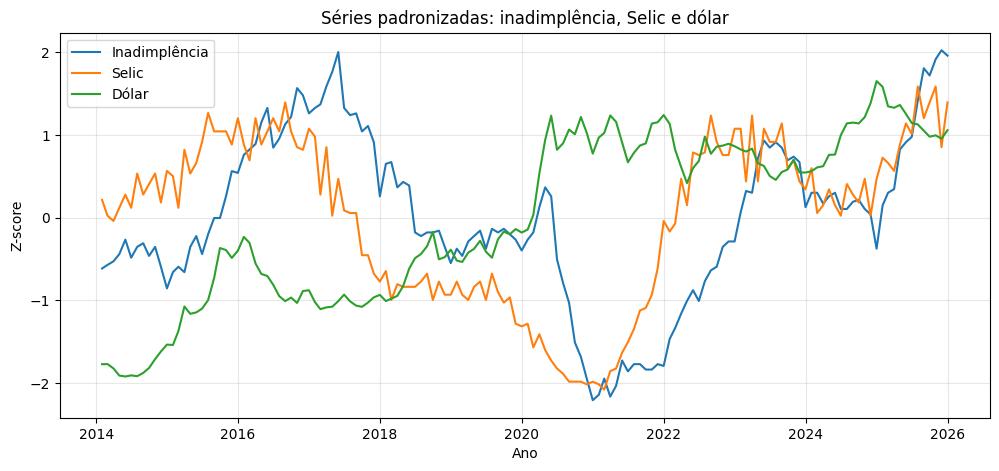

In [28]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=df_norm, x="data", y="inadimplencia_total_z", label="Inadimplência")
sns.lineplot(data=df_norm, x="data", y="selic_z", label="Selic")
sns.lineplot(data=df_norm, x="data", y="dolar_z", label="Dólar")

plt.title("Séries padronizadas: inadimplência, Selic e dólar")
plt.xlabel("Ano")
plt.ylabel("Z-score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Como inadimplência, Selic e dólar possuem unidades e escalas diferentes, as séries foram padronizadas por z-score. Com isso, é possível comparar visualmente seus movimentos relativos ao longo do tempo. Valores acima de zero indicam períodos em que a série esteve acima de sua média histórica no intervalo analisado; valores abaixo de zero indicam períodos abaixo da média.

In [29]:
cols_corr = ["inadimplencia_total", "selic", "dolar"]

corr_pearson = df_series[cols_corr].corr(method="pearson")
corr_spearman = df_series[cols_corr].corr(method="spearman")

corr_pearson

,inadimplencia_total,selic,dolar
inadimplencia_total,1.000000,0.596268,-0.219697
selic,0.596268,1.000000,-0.122375
dolar,-0.219697,-0.122375,1.000000


In [46]:
corr_spearman

,inadimplencia_total,selic,dolar
inadimplencia_total,1.000000,0.539416,-0.163263
selic,0.539416,1.000000,-0.093574
dolar,-0.163263,-0.093574,1.000000


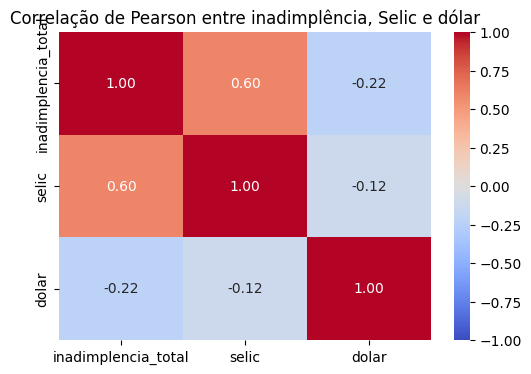

In [30]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_pearson,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlação de Pearson entre inadimplência, Selic e dólar")
plt.show()

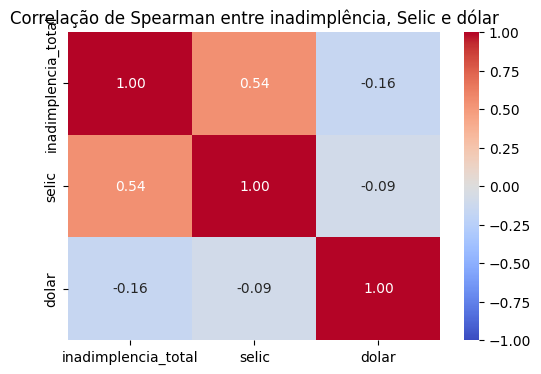

In [31]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlação de Spearman entre inadimplência, Selic e dólar")
plt.show()

Foram calculadas correlações de Pearson e Spearman. A correlação de Pearson mede associação linear entre as variáveis, enquanto a correlação de Spearman mede associação monotônica, sendo menos sensível a relações não lineares e valores extremos. Essa comparação permite avaliar se a inadimplência tende a se mover na mesma direção da Selic e do dólar no mesmo mês.

In [32]:
df_teste_selic = df_series.dropna(subset=["inadimplencia_total", "selic"])

r_selic, p_selic = pearsonr(
    df_teste_selic["inadimplencia_total"],
    df_teste_selic["selic"]
)

rho_selic, p_spearman_selic = spearmanr(
    df_teste_selic["inadimplencia_total"],
    df_teste_selic["selic"]
)

print("Pearson - Inadimplência x Selic")
print("r:", r_selic)
print("p-valor:", p_selic)

print("\nSpearman - Inadimplência x Selic")
print("rho:", rho_selic)
print("p-valor:", p_spearman_selic)

Pearson - Inadimplência x Selic
r: 0.5962675482106997
p-valor: 3.143666512197605e-15

Spearman - Inadimplência x Selic
rho: 0.5394160658861571
p-valor: 3.0425838562594004e-12


In [33]:
df_teste_dolar = df_series.dropna(subset=["inadimplencia_total", "dolar"])

r_dolar, p_dolar = pearsonr(
    df_teste_dolar["inadimplencia_total"],
    df_teste_dolar["dolar"]
)

rho_dolar, p_spearman_dolar = spearmanr(
    df_teste_dolar["inadimplencia_total"],
    df_teste_dolar["dolar"]
)

print("Pearson - Inadimplência x dólar")
print("r:", r_dolar)
print("p-valor:", p_dolar)

print("\nSpearman - Inadimplência x dólar")
print("rho:", rho_dolar)
print("p-valor:", p_spearman_dolar)

Pearson - Inadimplência x dólar
r: -0.21969686713356704
p-valor: 0.00814999915890801

Spearman - Inadimplência x dólar
rho: -0.16326301056790363
p-valor: 0.05055703083692122


### Testes de correlação

Foram aplicados testes de correlação para avaliar a associação entre a inadimplência e os indicadores macroeconômicos analisados.

Para cada par de variáveis, as hipóteses foram:

- H0: não há correlação estatisticamente significativa entre as variáveis.
- H1: há correlação estatisticamente significativa entre as variáveis.

O nível de significância adotado foi de 5%.

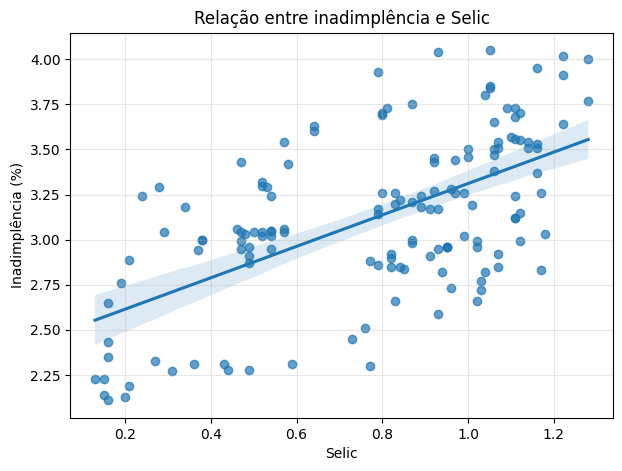

In [34]:
plt.figure(figsize=(7, 5))

sns.regplot(
    data=df_series,
    x="selic",
    y="inadimplencia_total",
    scatter_kws={"alpha": 0.7}
)

plt.title("Relação entre inadimplência e Selic")
plt.xlabel("Selic")
plt.ylabel("Inadimplência (%)")
plt.grid(True, alpha=0.3)
plt.show()

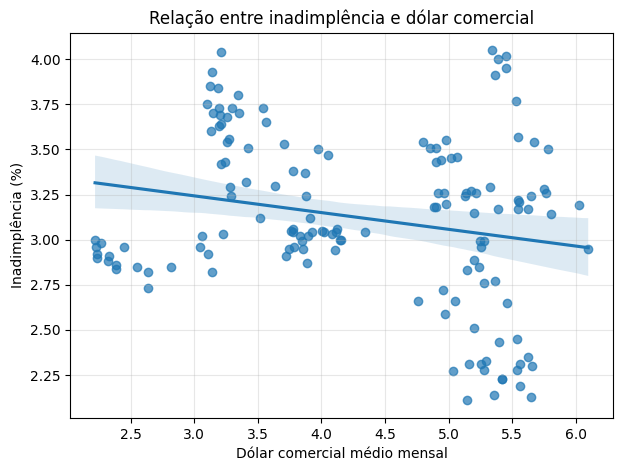

In [35]:
plt.figure(figsize=(7, 5))

sns.regplot(
    data=df_series,
    x="dolar",
    y="inadimplencia_total",
    scatter_kws={"alpha": 0.7}
)

plt.title("Relação entre inadimplência e dólar comercial")
plt.xlabel("Dólar comercial médio mensal")
plt.ylabel("Inadimplência (%)")
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
df_lag = df_series.copy()

for lag in range(1, 13):
    df_lag[f"selic_lag_{lag}"] = df_lag["selic"].shift(lag)
    df_lag[f"dolar_lag_{lag}"] = df_lag["dolar"].shift(lag)

In [37]:
corr_lags_selic = []

for lag in range(1, 13):
    temp = df_lag.dropna(subset=["inadimplencia_total", f"selic_lag_{lag}"])
    
    corr = temp["inadimplencia_total"].corr(temp[f"selic_lag_{lag}"])
    
    corr_lags_selic.append({
        "lag_meses": lag,
        "correlacao": corr
    })

corr_lags_selic = pd.DataFrame(corr_lags_selic)
corr_lags_selic

,lag_meses,correlacao
0,1,0.649566
1,2,0.697724
2,3,0.733332
3,4,0.769462
4,5,0.794509
5,6,0.812864
6,7,0.833513
7,8,0.845044
8,9,0.848373
9,10,0.851581


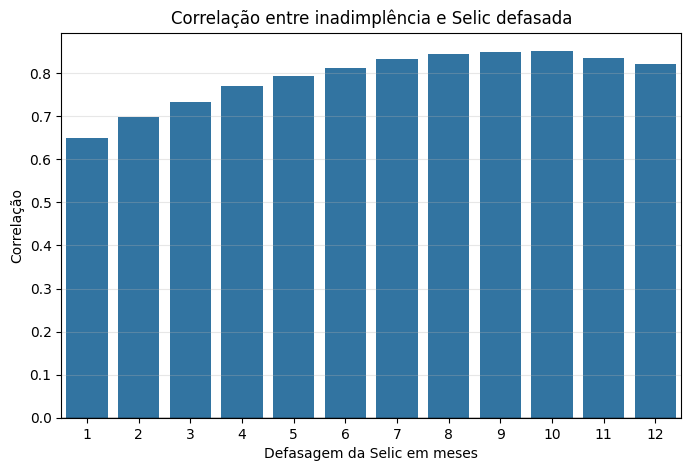

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=corr_lags_selic,
    x="lag_meses",
    y="correlacao"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Correlação entre inadimplência e Selic defasada")
plt.xlabel("Defasagem da Selic em meses")
plt.ylabel("Correlação")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [39]:
corr_lags_dolar = []

for lag in range(1, 13):
    temp = df_lag.dropna(subset=["inadimplencia_total", f"dolar_lag_{lag}"])
    
    corr = temp["inadimplencia_total"].corr(temp[f"dolar_lag_{lag}"])
    
    corr_lags_dolar.append({
        "lag_meses": lag,
        "correlacao": corr
    })

corr_lags_dolar = pd.DataFrame(corr_lags_dolar)
corr_lags_dolar

,lag_meses,correlacao
0,1,-0.221266
1,2,-0.218931
2,3,-0.213096
3,4,-0.202839
4,5,-0.191862
5,6,-0.182495
6,7,-0.168487
7,8,-0.156015
8,9,-0.148445
9,10,-0.138254


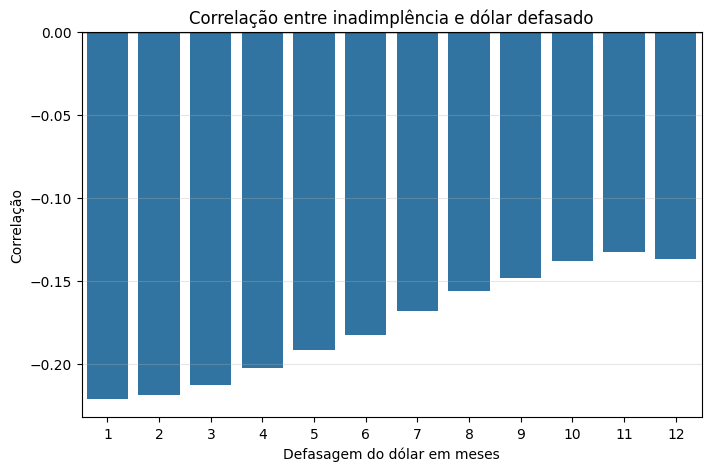

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=corr_lags_dolar,
    x="lag_meses",
    y="correlacao"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Correlação entre inadimplência e dólar defasado")
plt.xlabel("Defasagem do dólar em meses")
plt.ylabel("Correlação")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [ ]:
dolar_mensal = (
    dolar
    .set_index("data")
    .resample("M")
    .mean()
    .reset_index()
)

dolar_mensal.head()

C:\Users\User\AppData\Local\Temp\ipykernel_132596\2844460126.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,data,dolar
0,2014-01-31,2.382209
1,2014-02-28,2.383680
2,2014-03-31,2.326089
3,2014-04-30,2.232770
4,2014-05-31,2.220881


Também foram analisadas correlações com defasagens de 1 a 12 meses. Essa etapa é relevante porque alterações em juros e câmbio podem afetar a capacidade de pagamento dos agentes econômicos com algum atraso. Assim, a análise de lags permite investigar se Selic e dólar de meses anteriores apresentam associação maior com a inadimplência corrente.

In [41]:
melhor_lag_selic = corr_lags_selic.loc[
    corr_lags_selic["correlacao"].abs().idxmax()
]

melhor_lag_dolar = corr_lags_dolar.loc[
    corr_lags_dolar["correlacao"].abs().idxmax()
]

print("Maior correlação absoluta com Selic defasada:")
display(melhor_lag_selic)

print("Maior correlação absoluta com dólar defasado:")
display(melhor_lag_dolar)

Maior correlação absoluta com Selic defasada:


lag_meses     10.000000
correlacao     0.851581
Name: 9, dtype: float64

Maior correlação absoluta com dólar defasado:


lag_meses     1.000000
correlacao   -0.221266
Name: 0, dtype: float64

In [42]:
df_var = df_series.copy()

df_var["var_inadimplencia"] = df_var["inadimplencia_total"].diff()
df_var["var_selic"] = df_var["selic"].diff()
df_var["var_dolar_pct"] = df_var["dolar"].pct_change() * 100

df_var.head()

,data,inadimplencia_total,selic,dolar,ipca,ano,mes,ano_mes,inad_mm3,inad_mm12,var_inadimplencia,var_selic,var_dolar_pct
0,2014-01-31,2.84,0.85,2.382209,0.55,2014,1,2014-01,NaN,NaN,NaN,NaN,NaN
1,2014-02-28,2.86,0.79,2.383680,0.69,2014,2,2014-02,NaN,NaN,0.02,-0.06,0.061746
2,2014-03-31,2.88,0.77,2.326089,0.92,2014,3,2014-03,2.860000,NaN,0.02,-0.02,-2.416034
3,2014-04-30,2.92,0.82,2.232770,0.67,2014,4,2014-04,2.886667,NaN,0.04,0.05,-4.011861
4,2014-05-31,3.00,0.87,2.220881,0.46,2014,5,2014-05,2.933333,NaN,0.08,0.05,-0.532480


In [43]:
cols_var = ["var_inadimplencia", "var_selic", "var_dolar_pct"]

corr_var = df_var[cols_var].corr()

corr_var

,var_inadimplencia,var_selic,var_dolar_pct
var_inadimplencia,1.000000,0.048181,-0.071303
var_selic,0.048181,1.000000,0.037142
var_dolar_pct,-0.071303,0.037142,1.000000


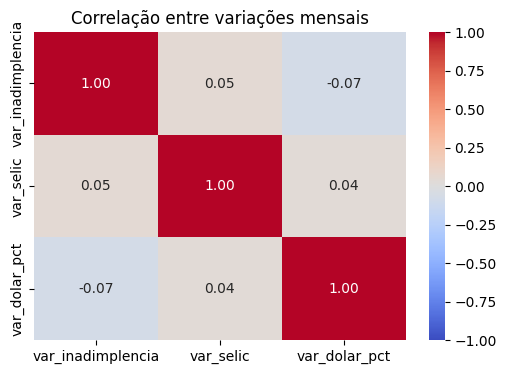

In [44]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_var,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlação entre variações mensais")
plt.show()

Além da análise em nível, foram calculadas as variações mensais das séries. Essa abordagem permite investigar se aumentos mensais na Selic ou no dólar coincidem com aumentos mensais da inadimplência. Como a inadimplência tende a responder de forma gradual a mudanças macroeconômicas, essa análise deve ser interpretada em conjunto com as correlações defasadas.

In [45]:
resumo_resultados = pd.DataFrame({
    "Indicador": [
        "Correlação Pearson: inadimplência x Selic",
        "Correlação Spearman: inadimplência x Selic",
        "Correlação Pearson: inadimplência x dólar",
        "Correlação Spearman: inadimplência x dólar",
        "Maior correlação absoluta Selic defasada",
        "Lag da maior correlação Selic",
        "Maior correlação absoluta dólar defasado",
        "Lag da maior correlação dólar"
    ],
    "Valor": [
        r_selic,
        rho_selic,
        r_dolar,
        rho_dolar,
        melhor_lag_selic["correlacao"],
        melhor_lag_selic["lag_meses"],
        melhor_lag_dolar["correlacao"],
        melhor_lag_dolar["lag_meses"]
    ]
})

resumo_resultados

,Indicador,Valor
0,Correlação Pearson: inadimplência x Selic,0.596268
1,Correlação Spearman: inadimplência x Selic,0.539416
2,Correlação Pearson: inadimplência x dólar,-0.219697
3,Correlação Spearman: inadimplência x dólar,-0.163263
4,Maior correlação absoluta Selic defasada,0.851581
5,Lag da maior correlação Selic,10.000000
6,Maior correlação absoluta dólar defasado,-0.221266
7,Lag da maior correlação dólar,1.000000
